In [1]:
# FLT3-Conserve: Conservation Analysis
# Weeks 6-8: Python Capstone

from Bio import SeqIO
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# Step 1: Read all 4 FASTA sequences from data/raw/

# Set the path to your data folder
data_path = "../data/raw/"

# Read each sequence
sequences = {}
for file in ["flt3_human.fasta", "MouseFLT3.fasta", "ChimpanzeeFLT3.fasta", "DogFLT3.fasta"]:
    record = SeqIO.read(data_path + file, "fasta")
    sequences[record.id] = str(record.seq)
    print(f"Loaded: {record.id} — {len(record.seq)} amino acids")

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/flt3_human.fasta'

In [3]:
import os

# Check current working directory
print("Current location:", os.getcwd())

# List files in data/raw relative to current location
print("\nFiles in data/raw:")
for f in os.listdir("../data/raw/"):
    print(f)

Current location: C:\Users\HP\Desktop\Bioinformatics\FLT3\FLT3-conservation-in-AML

Files in data/raw:


FileNotFoundError: [WinError 3] The system cannot find the path specified: '../data/raw/'

In [4]:
import os
print("Current location:", os.getcwd())

Current location: C:\Users\HP\Desktop\Bioinformatics\FLT3\FLT3-conservation-in-AML


In [5]:
import os
print(os.listdir("data/raw/"))

['ChimpanzeeFLT3.fasta', 'DogFLT3.fasta', 'flt3_all_species.fasta', 'flt3_human.fasta', 'flt3_mega.fasta', 'MouseFLT3.fasta', 'PhyloAnalysis.mdsx']


In [6]:
# Step 1: Read all 4 FASTA sequences from data/raw/

data_path = "data/raw/"

sequences = {}
for file in ["flt3_human.fasta", "MouseFLT3.fasta", "ChimpanzeeFLT3.fasta", "DogFLT3.fasta"]:
    record = SeqIO.read(data_path + file, "fasta")
    sequences[record.id] = str(record.seq)
    print(f"Loaded: {record.id} — {len(record.seq)} amino acids")


Loaded: NP_004110.2 — 993 amino acids
Loaded: NP_034359.2 — 1000 amino acids
Loaded: XP_509601.2 — 993 amino acids
Loaded: AAY25025.1 — 993 amino acids


In [7]:
# Step 2: Calculate conservation score for each position
# Using the combined file we already aligned in MEGA/ClustalW

from Bio import AlignIO

# Load the aligned file
alignment = AlignIO.read("data/raw/flt3_all_species.fasta", "fasta")

print(f"Number of sequences: {len(alignment)}")
print(f"Alignment length: {alignment.get_alignment_length()} positions")

ValueError: Sequences must all be the same length

In [8]:
from Bio import AlignIO

# Load the MEGA-aligned file
alignment = AlignIO.read("data/raw/flt3_aligned.fasta", "fasta")

print(f"Number of sequences: {len(alignment)}")
print(f"Alignment length: {alignment.get_alignment_length()} positions")

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/flt3_aligned.fasta'

In [9]:
from Bio import AlignIO

# Load the MEGA-aligned file
alignment = AlignIO.read("data/raw/flt3_aligned.fasta", "fasta")

print(f"Number of sequences: {len(alignment)}")
print(f"Alignment length: {alignment.get_alignment_length()} positions")

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/flt3_aligned.fasta'

In [10]:
import os
print(os.listdir("data/raw/"))

['ChimpanzeeFLT3.fasta', 'DogFLT3.fasta', 'flt3_aligned.fas', 'flt3_all_species.fasta', 'flt3_human.fasta', 'flt3_mega.fasta', 'MouseFLT3.fasta', 'PhyloAnalysis.mdsx']


In [11]:
from Bio import AlignIO

# Load the MEGA-aligned file
alignment = AlignIO.read("data/raw/flt3_aligned.fasta", "fasta")

print(f"Number of sequences: {len(alignment)}")
print(f"Alignment length: {alignment.get_alignment_length()} positions")

Number of sequences: 4
Alignment length: 1000 positions


In [12]:
# Step 3: Calculate conservation score for each position

conservation_scores = []

for i in range(alignment.get_alignment_length()):
    # Get the amino acid at this position for all 4 species
    column = alignment[:, i]
    
    # Count the most common amino acid
    most_common = max(set(column), key=column.count)
    score = column.count(most_common) / len(column)
    
    conservation_scores.append(score)

print(f"Total positions scored: {len(conservation_scores)}")
print(f"Average conservation: {sum(conservation_scores)/len(conservation_scores):.2f}")
print(f"Fully conserved positions: {conservation_scores.count(1.0)}")

Total positions scored: 1000
Average conservation: 0.94
Fully conserved positions: 810


In [13]:
# Step 4: Build a Pandas dataframe

positions = list(range(1, len(conservation_scores) + 1))

df = pd.DataFrame({
    "position": positions,
    "conservation_score": conservation_scores
})

# Mark domains
df["domain"] = "other"
df.loc[(df["position"] >= 591) & (df["position"] <= 597), "domain"] = "juxtamembrane"
df.loc[(df["position"] >= 610) & (df["position"] <= 943), "domain"] = "kinase"

# Mark mutation sites
df["mutation_site"] = "no"
df.loc[df["position"] == 835, "mutation_site"] = "D835Y"
df.loc[(df["position"] >= 571) & (df["position"] <= 620), "mutation_site"] = "ITD_region"

print(df.head(10))
print(f"\nDomain counts:\n{df['domain'].value_counts()}")

   position  conservation_score domain mutation_site
0         1                1.00  other            no
1         2                0.75  other            no
2         3                1.00  other            no
3         4                1.00  other            no
4         5                1.00  other            no
5         6                0.75  other            no
6         7                0.50  other            no
7         8                0.75  other            no
8         9                0.75  other            no
9        10                0.75  other            no

Domain counts:
domain
other            659
kinase           334
juxtamembrane      7
Name: count, dtype: int64


In [14]:
# Check our key mutation sites
print("Position 835 (D835Y site):")
print(df[df["position"] == 835])

print("\nJuxtamembrane region (591-597):")
print(df[df["domain"] == "juxtamembrane"])

print("\nMean conservation by domain:")
print(df.groupby("domain")["conservation_score"].mean().round(3))

Position 835 (D835Y site):
     position  conservation_score  domain mutation_site
834       835                 1.0  kinase         D835Y

Juxtamembrane region (591-597):
     position  conservation_score         domain mutation_site
590       591                1.00  juxtamembrane    ITD_region
591       592                1.00  juxtamembrane    ITD_region
592       593                0.75  juxtamembrane    ITD_region
593       594                1.00  juxtamembrane    ITD_region
594       595                1.00  juxtamembrane    ITD_region
595       596                1.00  juxtamembrane    ITD_region
596       597                0.75  juxtamembrane    ITD_region

Mean conservation by domain:
domain
juxtamembrane    0.929
kinase           0.970
other            0.927
Name: conservation_score, dtype: float64


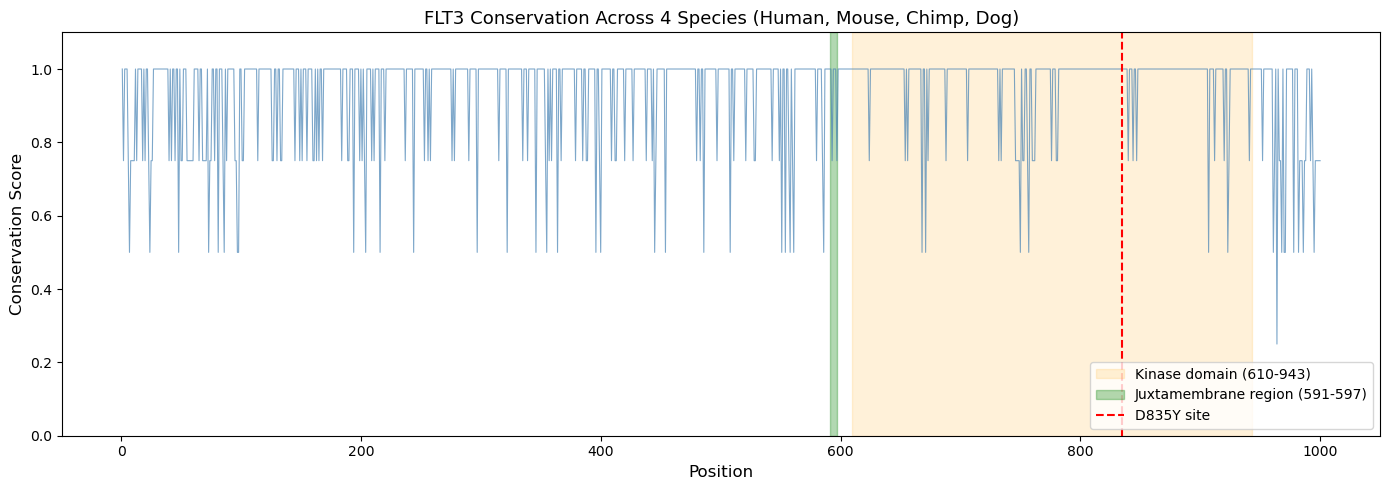

Plot saved to results/FLT3_conservation_plot.png


In [15]:
# Step 5: Plot conservation across all 1000 positions

fig, ax = plt.subplots(figsize=(14, 5))

# Plot conservation score
ax.plot(df["position"], df["conservation_score"], 
        color="steelblue", linewidth=0.8, alpha=0.7)

# Highlight kinase domain
ax.axvspan(610, 943, alpha=0.15, color="orange", label="Kinase domain (610-943)")

# Highlight juxtamembrane region
ax.axvspan(591, 597, alpha=0.3, color="green", label="Juxtamembrane region (591-597)")

# Mark D835
ax.axvline(x=835, color="red", linewidth=1.5, linestyle="--", label="D835Y site")

# Labels and formatting
ax.set_xlabel("Position", fontsize=12)
ax.set_ylabel("Conservation Score", fontsize=12)
ax.set_title("FLT3 Conservation Across 4 Species (Human, Mouse, Chimp, Dog)", fontsize=13)
ax.legend(loc="lower right")
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig("results/FLT3_conservation_plot.png", dpi=150)
plt.show()

print("Plot saved to results/FLT3_conservation_plot.png")

In [16]:
!git add results/FLT3_conservation_plot.png
!git add notebooks/conservation_analysis.ipynb
!git commit -m "Weeks 6-8: Python conservation scoring and visualization"
!git push

fatal: pathspec 'notebooks/conservation_analysis.ipynb' did not match any files


[main a9db308] Weeks 6-8: Python conservation scoring and visualization
 1 file changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 results/FLT3_conservation_plot.png


remote: This repository moved. Please use the new location:        
remote:   https://github.com/MuhdSuraj/FLT3-conservation-in-AML.git        
To https://github.com/MuhammadSurajDuwa/FLT3-conservation-in-AML.git
   8f96549..a9db308  main -> main
